# DecodeLabs Internship - Project 4: Data Visualization

This project focuses on creating clear visual representations of the cleaned dataset to communicate business insights effectively.

The goal is to move from exploratory analysis to explanatory storytelling using appropriate charts and action-oriented insights.

In [29]:
import pandas as pd

In [30]:
from google.colab import files
uploaded = files.upload()
#uploaded = files.upload

Saving Decode_Project1_Final_Output.xlsx to Decode_Project1_Final_Output (1).xlsx


In [31]:
file_path = list(uploaded.keys())[0]
print(file_path)

Decode_Project1_Final_Output (1).xlsx


In [32]:
import matplotlib.pyplot as plt
import os

In [33]:
df = pd.read_excel(file_path, sheet_name="Cleaned Dataset")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [34]:
charts_folder = "charts"
os.makedirs(charts_folder, exist_ok=True)

In [35]:
product_revenue = df.groupby("Product")["TotalPrice"].sum().reset_index()

product_revenue = product_revenue.sort_values(by="TotalPrice", ascending=False)

product_revenue["TotalPrice"] = product_revenue["TotalPrice"].round(2)

product_revenue

,Product,TotalPrice
0,Chair,195620.11
5,Printer,195612.61
2,Laptop,192126.56
6,Tablet,186568.95
3,Monitor,175651.41
1,Desk,167459.93
4,Phone,151722.39


In [36]:
status_percentage = df["OrderStatus"].value_counts(normalize=True).reset_index()

status_percentage.columns = ["OrderStatus", "Percentage"]

status_percentage["Percentage"] = (status_percentage["Percentage"] * 100).round(2)

status_percentage

,OrderStatus,Percentage
0,Cancelled,20.83
1,Returned,20.58
2,Pending,19.75
3,Shipped,19.58
4,Delivered,19.25


In [37]:
# Make sure column names have no extra spaces
df.columns = df.columns.str.strip()

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Check if conversion worked
print(df["Date"].dtype)
print("Invalid dates:", df["Date"].isna().sum())

datetime64[ns]
Invalid dates: 0


In [38]:
df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)

monthly_revenue = df.groupby("YearMonth")["TotalPrice"].sum().reset_index()

monthly_revenue = monthly_revenue.sort_values("YearMonth")

monthly_revenue["TotalPrice"] = monthly_revenue["TotalPrice"].round(2)

monthly_revenue.head()

,YearMonth,TotalPrice
0,2023-01,56685.75
1,2023-02,40117.66
2,2023-03,48609.37
3,2023-04,27751.71
4,2023-05,63836.84


In [39]:
referral_revenue = df.groupby("ReferralSource")["TotalPrice"].sum().reset_index()

referral_revenue = referral_revenue.sort_values(by="TotalPrice", ascending=False)

referral_revenue["TotalPrice"] = referral_revenue["TotalPrice"].round(2)

referral_revenue

,ReferralSource,TotalPrice
3,Instagram,275285.45
0,Email,261808.55
2,Google,250441.48
1,Facebook,250410.90
4,Referral,226815.58


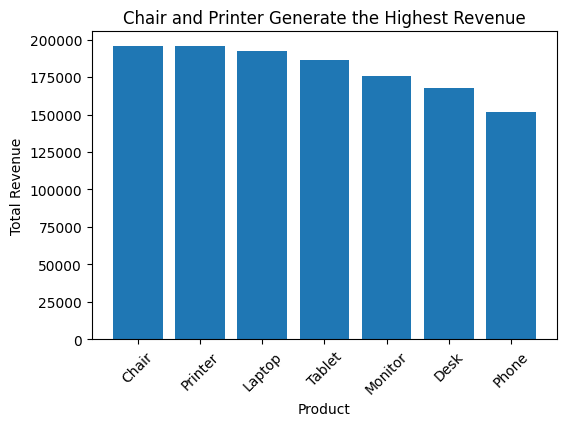

In [40]:
plt.figure(figsize=(6, 4))

plt.bar(product_revenue["Product"], product_revenue["TotalPrice"])

plt.title("Chair and Printer Generate the Highest Revenue")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.savefig("charts/revenue_by_product.png", bbox_inches="tight")
plt.show()

### Insight 1: Product Revenue

Chair and Printer are the top revenue-generating products, with very close revenue values. This indicates that both products are strong performers and should be prioritized in sales and inventory planning.

In [41]:
status_percentage = df["OrderStatus"].value_counts(normalize=True).reset_index()

status_percentage.columns = ["OrderStatus", "Percentage"]

status_percentage["Percentage"] = (status_percentage["Percentage"] * 100).round(2)

status_percentage

,OrderStatus,Percentage
0,Cancelled,20.83
1,Returned,20.58
2,Pending,19.75
3,Shipped,19.58
4,Delivered,19.25


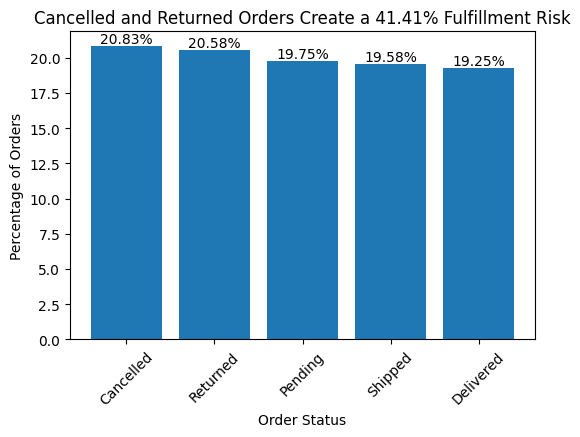

In [42]:
os.makedirs("charts", exist_ok=True)

# Calculate combined risk
cancelled_pct = status_percentage.loc[
    status_percentage["OrderStatus"] == "Cancelled",
    "Percentage"
].values[0]

returned_pct = status_percentage.loc[
    status_percentage["OrderStatus"] == "Returned",
    "Percentage"
].values[0]

risk_pct = round(cancelled_pct + returned_pct, 2)

# Plot
plt.figure(figsize=(6, 4))

bars = plt.bar(
    status_percentage["OrderStatus"],
    status_percentage["Percentage"]
)

plt.title(f"Cancelled and Returned Orders Create a {risk_pct}% Fulfillment Risk")
plt.xlabel("Order Status")
plt.ylabel("Percentage of Orders")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height}%",
        ha="center",
        va="bottom"
    )

plt.savefig("charts/order_status_fulfillment_risk.png", bbox_inches="tight")
plt.show()

### Insight 2: Order Status Risk

Cancelled and Returned orders together represent 41.41% of total orders. This may indicate a potential fulfillment, delivery, product expectation, or customer satisfaction issue.

This chart highlights that the business should investigate the main causes behind cancellations and returns before focusing only on increasing sales.

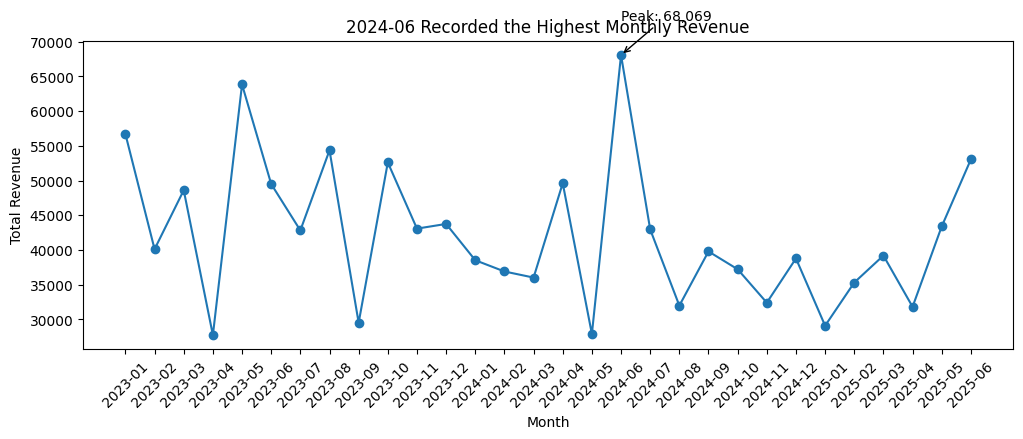

,YearMonth,TotalPrice
0,2023-01,56685.75
1,2023-02,40117.66
2,2023-03,48609.37
3,2023-04,27751.71
4,2023-05,63836.84


In [43]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)

monthly_revenue = df.groupby("YearMonth")["TotalPrice"].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values("YearMonth")
monthly_revenue["TotalPrice"] = monthly_revenue["TotalPrice"].round(2)

best_month_row = monthly_revenue.sort_values("TotalPrice", ascending=False).iloc[0]
best_month = best_month_row["YearMonth"]
best_month_revenue = best_month_row["TotalPrice"]

# Plot
plt.figure(figsize=(12, 4))

plt.plot(
    monthly_revenue["YearMonth"],
    monthly_revenue["TotalPrice"],
    marker="o"
)

plt.title(f"{best_month} Recorded the Highest Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.annotate(
    f"Peak: {best_month_revenue:,.0f}",
    xy=(best_month, best_month_revenue),
    xytext=(best_month, best_month_revenue + 5000),
    arrowprops=dict(arrowstyle="->")
)

plt.savefig("charts/monthly_revenue_trend.png", bbox_inches="tight")
plt.show()

monthly_revenue.head()

### Insight 3: Monthly Revenue Trend

Monthly revenue fluctuates across the dataset period. The strongest revenue month was 2024-06, which indicates a clear performance peak that should be investigated for possible seasonality, campaign impact, or product mix.

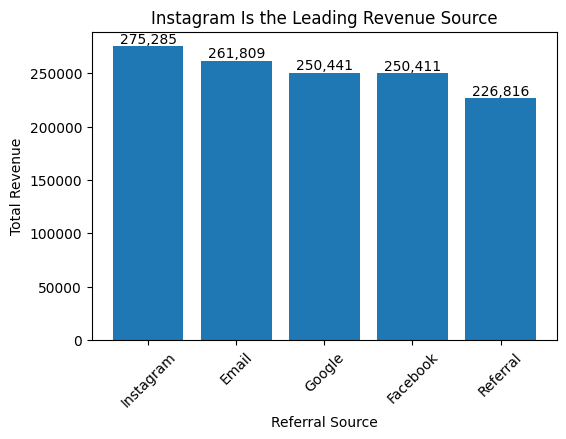

,ReferralSource,TotalPrice
3,Instagram,275285.45
0,Email,261808.55
2,Google,250441.48
1,Facebook,250410.90
4,Referral,226815.58


In [44]:
# Revenue by referral source
referral_revenue = df.groupby("ReferralSource")["TotalPrice"].sum().reset_index()
referral_revenue = referral_revenue.sort_values(by="TotalPrice", ascending=False)
referral_revenue["TotalPrice"] = referral_revenue["TotalPrice"].round(2)

top_source = referral_revenue.iloc[0]["ReferralSource"]

# Plot
plt.figure(figsize=(6, 4))

bars = plt.bar(
    referral_revenue["ReferralSource"],
    referral_revenue["TotalPrice"]
)

plt.title(f"{top_source} Is the Leading Revenue Source")
plt.xlabel("Referral Source")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.savefig("charts/revenue_by_referral_source.png", bbox_inches="tight")
plt.show()

referral_revenue

### Insight 4: Referral Source Revenue

The leading referral source generates the highest revenue contribution. This indicates that marketing effort should focus more on the strongest-performing acquisition channels while reviewing weaker sources.

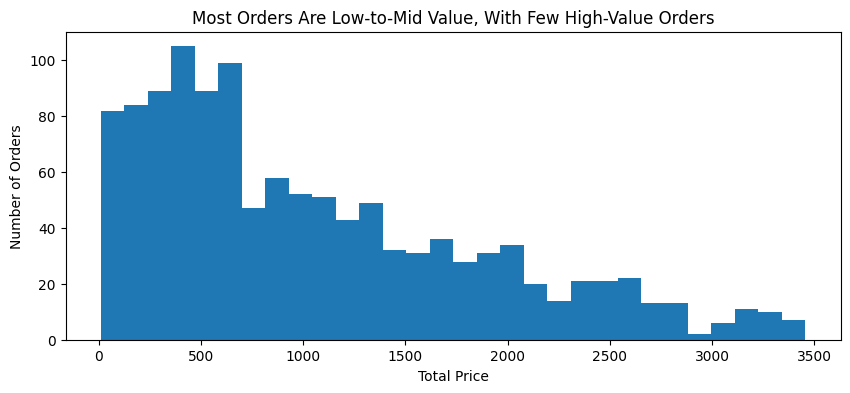

In [45]:
# TotalPrice distribution
plt.figure(figsize=(10, 4))

plt.hist(df["TotalPrice"], bins=30)

plt.title("Most Orders Are Low-to-Mid Value, With Few High-Value Orders")
plt.xlabel("Total Price")
plt.ylabel("Number of Orders")

plt.savefig("charts/totalprice_distribution.png", bbox_inches="tight")
plt.show()

### Insight 5: TotalPrice Distribution

TotalPrice is right-skewed. Most orders are low-to-medium value, while a small number of high-value orders increase the average order value. These high-value transactions should be investigated as potential VIP or premium customer behavior.

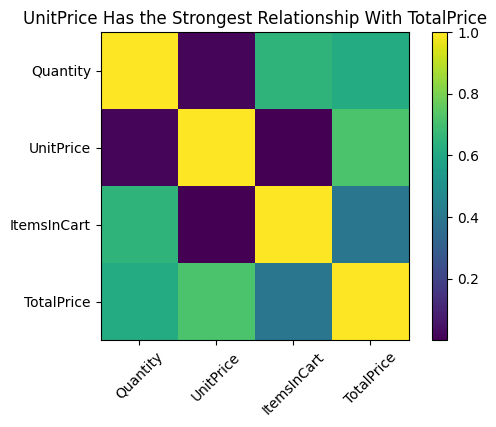

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.00,0.01,0.65,0.62
UnitPrice,0.01,1.00,0.00,0.72
ItemsInCart,0.65,0.00,1.00,0.39
TotalPrice,0.62,0.72,0.39,1.00


In [46]:
# Numeric columns
numeric_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]

# Correlation matrix
correlation_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(6, 4))

plt.imshow(correlation_matrix)
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("UnitPrice Has the Strongest Relationship With TotalPrice")

plt.savefig("charts/correlation_matrix.png", bbox_inches="tight")
plt.show()

correlation_matrix.round(2)

### Insight 6: Correlation Analysis

The strongest relationship is between UnitPrice and TotalPrice. This suggests that higher-priced products have a stronger impact on total order value than basket size alone. However, correlation does not prove causation.

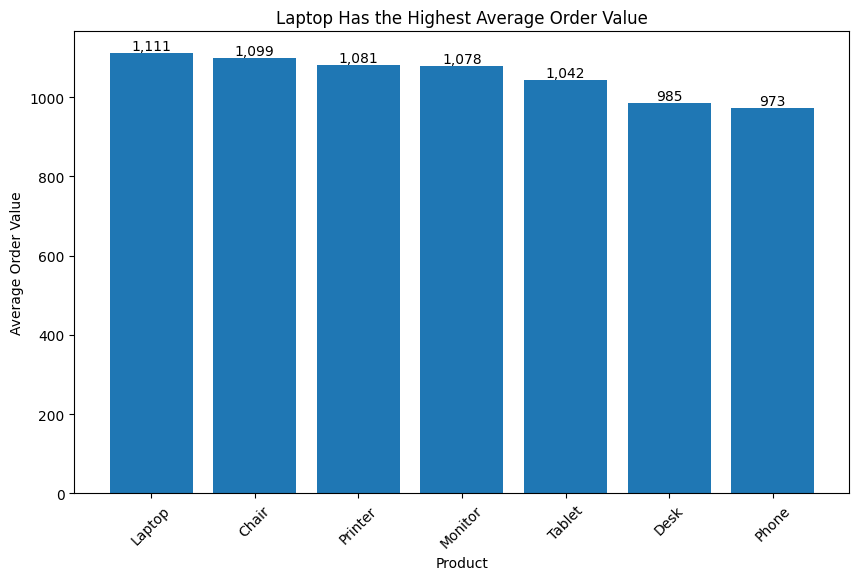

,Product,TotalPrice
2,Laptop,1110.56
0,Chair,1098.99
5,Printer,1080.73
3,Monitor,1077.62
6,Tablet,1042.28
1,Desk,985.06
4,Phone,972.58


In [47]:
# Average order value by product
product_aov = df.groupby("Product")["TotalPrice"].mean().reset_index()
product_aov = product_aov.sort_values(by="TotalPrice", ascending=False)
product_aov["TotalPrice"] = product_aov["TotalPrice"].round(2)

top_aov_product = product_aov.iloc[0]["Product"]

# Plot
plt.figure(figsize=(10, 6))

bars = plt.bar(
    product_aov["Product"],
    product_aov["TotalPrice"]
)

plt.title(f"{top_aov_product} Has the Highest Average Order Value")
plt.xlabel("Product")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.savefig("charts/aov_by_product.png", bbox_inches="tight")
plt.show()

product_aov

### Insight 7: Average Order Value by Product

Average order value differs by product, which means not all products contribute equally to revenue quality. Products with higher average order value should be prioritized in upselling and promotional strategies.

In [48]:

os.makedirs("charts", exist_ok=True)

# Recalculate important values safely
top_products = product_revenue.head(2)["Product"].tolist()

cancelled_pct = status_percentage.loc[
    status_percentage["OrderStatus"] == "Cancelled",
    "Percentage"
].values[0]

returned_pct = status_percentage.loc[
    status_percentage["OrderStatus"] == "Returned",
    "Percentage"
].values[0]

risk_pct = round(cancelled_pct + returned_pct, 2)

best_month_row = monthly_revenue.sort_values("TotalPrice", ascending=False).iloc[0]
best_month = best_month_row["YearMonth"]
best_month_revenue = best_month_row["TotalPrice"]

top_source = referral_revenue.iloc[0]["ReferralSource"]
top_aov_product = product_aov.iloc[0]["Product"]

# Sheet 1: Visualization Plan
visualization_plan = pd.DataFrame({
    "Business Question": [
        "Which products generate the highest revenue?",
        "Is there a fulfillment or customer satisfaction risk?",
        "How does revenue change over time?",
        "Which referral source generates the highest revenue?",
        "What is the distribution of order value?",
        "Which numeric variables are most related?",
        "Which product has the highest average order value?"
    ],
    "Chart Type": [
        "Bar Chart",
        "Bar Chart",
        "Line Chart",
        "Bar Chart",
        "Histogram",
        "Correlation Heatmap",
        "Bar Chart"
    ],
    "Reason for Choosing Chart": [
        "Best for comparing revenue across product categories",
        "Best for comparing order status percentages",
        "Best for showing revenue trend over time",
        "Best for comparing revenue across acquisition channels",
        "Best for understanding spread and skewness",
        "Best for showing relationships between numeric variables",
        "Best for comparing average order value by product"
    ],
    "Action Title": [
        "Chair and Printer Generate the Highest Revenue",
        f"Cancelled and Returned Orders Create a {risk_pct}% Fulfillment Risk",
        f"{best_month} Recorded the Highest Monthly Revenue",
        f"{top_source} Is the Leading Revenue Source",
        "Most Orders Are Low-to-Mid Value, With Few High-Value Orders",
        "UnitPrice Has the Strongest Relationship With TotalPrice",
        f"{top_aov_product} Has the Highest Average Order Value"
    ]
})

# Sheet 2: Key Insights
key_insights = pd.DataFrame({
    "Insight Number": [
        1, 2, 3, 4, 5, 6, 7
    ],
    "Insight": [
        "Chair and Printer are the top revenue-generating products.",
        f"Cancelled and Returned orders together represent {risk_pct}% of total orders.",
        f"{best_month} recorded the highest monthly revenue.",
        f"{top_source} is the leading referral source by revenue.",
        "TotalPrice is right-skewed, meaning most orders are low-to-medium value with a few high-value orders.",
        "UnitPrice has the strongest relationship with TotalPrice.",
        f"{top_aov_product} has the highest average order value."
    ],
    "Business Meaning": [
        "These products should be prioritized in inventory and sales planning.",
        "The business should investigate cancellation and return reasons before focusing only on more sales.",
        "The peak month should be reviewed to identify seasonality, campaign impact, or product mix effects.",
        "Marketing efforts can be optimized by focusing on the strongest acquisition source.",
        "High-value orders may represent premium customers or bulk purchases.",
        "Product price is a key driver of total order value.",
        "This product may be useful for upselling or premium targeting."
    ]
})

# Sheet 3: Recommendations
recommendations = pd.DataFrame({
    "Recommendation": [
        "Prioritize Chair and Printer in stock planning and promotions.",
        "Investigate the reasons behind cancelled and returned orders.",
        "Analyze the activities or campaigns that happened during the best revenue month.",
        "Increase focus on the highest-performing referral source.",
        "Study high-value orders to understand premium customer behavior.",
        "Use pricing and product mix strategy to improve total revenue.",
        "Use clean, simple, and action-oriented visualizations for executive reporting."
    ]
})

# Sheet 4: Chart Files
chart_files = pd.DataFrame({
    "Chart File": sorted(os.listdir("charts"))
})

# Create Excel report
output_file = "Decode_Project4_Visualization_Report.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    visualization_plan.to_excel(writer, sheet_name="Visualization Plan", index=False)
    key_insights.to_excel(writer, sheet_name="Key Insights", index=False)
    recommendations.to_excel(writer, sheet_name="Recommendations", index=False)
    product_revenue.to_excel(writer, sheet_name="Revenue by Product", index=False)
    status_percentage.to_excel(writer, sheet_name="Order Status", index=False)
    monthly_revenue.to_excel(writer, sheet_name="Monthly Revenue", index=False)
    referral_revenue.to_excel(writer, sheet_name="Referral Revenue", index=False)
    product_aov.to_excel(writer, sheet_name="AOV by Product", index=False)
    correlation_matrix.round(2).to_excel(writer, sheet_name="Correlation Matrix")
    chart_files.to_excel(writer, sheet_name="Chart Files", index=False)

print("Excel report created successfully:", output_file)

Excel report created successfully: Decode_Project4_Visualization_Report.xlsx


In [49]:
readme_text = """
# DecodeLabs Internship - Project 4: Data Visualization

## Project Overview

This project focuses on creating clear visual representations of cleaned sales data to communicate business insights effectively.

The main goal is to move from exploratory analysis to explanatory storytelling by choosing appropriate charts, writing action-oriented chart titles, and highlighting key business insights.

## Dataset Used

The project uses the cleaned dataset from Project 1:

- `Decode_Project1_Final_Output.xlsx`
- Sheet used: `Cleaned Dataset`

## Tools Used

- Python
- Google Colab
- Pandas
- Matplotlib
- Excel

## Main Objectives

- Create visual charts to communicate insights clearly.
- Choose suitable chart types for each business question.
- Highlight key findings using action titles.
- Avoid misleading or cluttered charts.
- Build a clear visual story for business decision-making.

## Charts Created

1. Revenue by Product
2. Order Status Fulfillment Risk
3. Monthly Revenue Trend
4. Revenue by Referral Source
5. TotalPrice Distribution
6. Correlation Matrix
7. Average Order Value by Product

## Key Insights

1. Chair and Printer generate the highest revenue.
2. Cancelled and Returned orders together create a major fulfillment risk.
3. The highest monthly revenue was recorded in the strongest performance month.
4. The leading referral source contributes the highest revenue.
5. Most orders are low-to-medium value, with a few high-value orders.
6. UnitPrice has the strongest relationship with TotalPrice.
7. Average order value differs across products.

## Business Recommendations

- Prioritize high-revenue products in inventory and sales planning.
- Investigate cancellation and return reasons.
- Review the best revenue month to understand performance drivers.
- Focus marketing efforts on the strongest referral source.
- Study high-value orders for premium customer behavior.
- Use clean, simple, and action-oriented visualizations for reporting.

## Project Files

- `decode_project_4_visualization.ipynb`
- `Decode_Project4_Visualization_Report.xlsx`
- `charts/`
- `README.md`

## Author

Data Analytics Internship Project - DecodeLabs
"""

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme_text)

print("README.md created successfully.")

README.md created successfully.


In [50]:
import shutil

project_folder = "Week_04_Data_Visualization"

os.makedirs(project_folder, exist_ok=True)

# Copy report and README
shutil.copy("Decode_Project4_Visualization_Report.xlsx", project_folder)
shutil.copy("README.md", project_folder)

# Copy charts folder
if os.path.exists(f"{project_folder}/charts"):
    shutil.rmtree(f"{project_folder}/charts")

shutil.copytree("charts", f"{project_folder}/charts")

# Create zip
shutil.make_archive(project_folder, "zip", project_folder)

print("ZIP file created successfully:", project_folder + ".zip")

ZIP file created successfully: Week_04_Data_Visualization.zip


In [51]:
from google.colab import files

files.download("Week_04_Data_Visualization.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>